In [2]:
!pip install langdetect emoji contractions -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import re
import emoji
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
data = pd.read_csv('daraz-code-mixed-product-reviews.csv')
data.head()

,Sentiments,Reviews
0,negative,Stuff and design was totally changed. cheap qu...
1,positive,"i got my parxel before time,sorry for late rev..."
2,positive,So far so good..... Bought it only because it ...
3,neutral,Received as described but not suitable such ha...
4,positive,Received on time and in a safely packed box. T...


In [6]:
# Map text labels to numbers
sentiment_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
data['Label'] = data['Sentiments'].map(sentiment_mapping)

# Check the distribution to see if the dataset is balanced
print(data['Label'].value_counts())

Label
2    10167
0     4362
1     2461
Name: count, dtype: int64


In [7]:
data.head()

,Sentiments,Reviews,Label
0,negative,Stuff and design was totally changed. cheap qu...,0
1,positive,"i got my parxel before time,sorry for late rev...",2
2,positive,So far so good..... Bought it only because it ...,2
3,neutral,Received as described but not suitable such ha...,1
4,positive,Received on time and in a safely packed box. T...,2


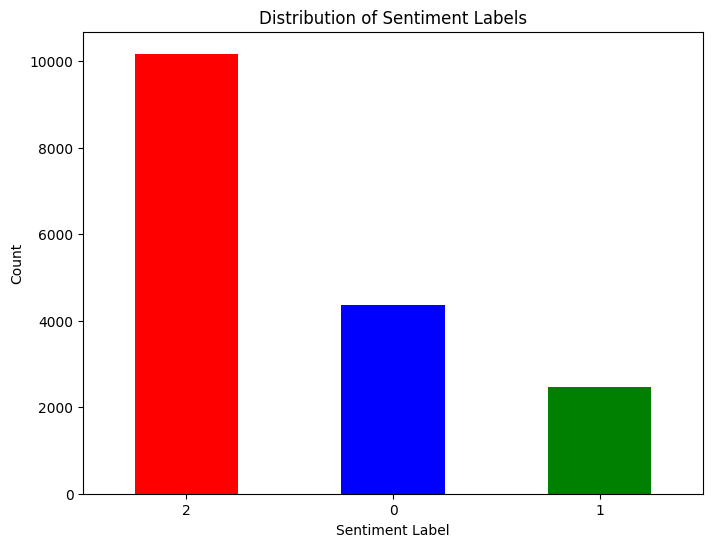

In [ ]:
ax = data['Sentiments'].value_counts().plot(kind='bar', figsize=(8, 6), color=['red', 'blue', 'green'])
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Count')
for label in ax.get_xticklabels():
    label.set_rotation(0)
    label.set_ha('center')
    label.set_va('top')

plt.savefig('sentiment_distribution.png', bbox_inches='tight')
plt.show()

In [ ]:
import re
import emoji
import pandas as pd

# -----------------------------
# 1. Emoji Sentiment Mapping
# -----------------------------
emoji_map = {
    "😊": "positive",
    "😀": "positive",
    "😍": "positive",
    "❤️": "positive",
    "👍": "positive",

    "😢": "negative",
    "😭": "negative",
    "😡": "negative",
    "👎": "negative",
    "💔": "negative",

    "😐": "neutral"
}

# -----------------------------
# 2. Roman Urdu + English Slang Map
# -----------------------------
roman_urdu_map = {
    "bht": "bohot",
    "boht": "bohot",
    "bohut": "bohot",
    "bohat": "bohot",

    "acha": "acha",
    "achi": "acha",
    "achha": "acha",

    "bakwas": "bekar",
    "fazool": "bekar",

    "thk": "theek",
    "thik": "theek",

    "nhi": "nahi",
    "nai": "nahi",
    "nahee": "nahi",

    "kr": "kar",
    "krna": "karna",

    "mje": "mujhe",
    "mjhe": "mujhe",

    "phr": "phir",

    "plz": "please",
    "pls": "please",

    "gud": "good",
    "gr8": "great",
    "nyc": "nice",
    "luv": "love"
}

# -----------------------------
# 3. Emoji Converter Function
# -----------------------------
def convert_emojis(text):
    for e, meaning in emoji_map.items():
        text = text.replace(e, f" {meaning} ")
    return text

# -----------------------------
# 4. Main Preprocessing Function
# -----------------------------
def preprocess_roman_urdu(text):

    if not isinstance(text, str):
        return ""

    # 1. Lowercase
    text = text.lower()

    # 2. Convert emojis
    text = convert_emojis(text)

    # 3. Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # 4. Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # 5. Remove repeated characters (bohoooot → bohot)
    text = re.sub(r"(.)\1{2,}", r"\1", text)

    # 6. Normalize Roman Urdu + English slang
    for pattern, replacement in roman_urdu_map.items():
        text = re.sub(rf"\b{pattern}\b", replacement, text)

    # 7. Remove special characters (keep letters & spaces)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # 8. Remove numbers
    text = re.sub(r"\d+", "", text)

    # 9. Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # 10. Remove duplicate consecutive words
    words = text.split()
    cleaned_words = []

    for w in words:
        if len(cleaned_words) == 0 or cleaned_words[-1] != w:
            cleaned_words.append(w)

    text = " ".join(cleaned_words)

    return text

# -----------------------------
# 5. Apply to Dataset
# -----------------------------
data = pd.read_csv("daraz-code-mixed-product-reviews.csv")  # change filename if needed

data["Clean_Review"] = data["Reviews"].apply(preprocess_roman_urdu)
ndata["Label"] = data["Sentiments"].map({'negative': 0, 'neutral': 1, 'positive': 2})

data[["Reviews", "Clean_Review"]].head(5)

,Reviews,Clean_Review
0,Stuff and design was totally changed. cheap qu...,stuff and design was totally changed cheap qua...
1,"i got my parxel before time,sorry for late rev...",i got my parxel before time sorry for late rev...
2,So far so good..... Bought it only because it ...,so far so good bought it only because it has t...
3,Received as described but not suitable such ha...,received as described but not suitable such ha...
4,Received on time and in a safely packed box. T...,received on time and in a safely packed box th...


In [26]:
# Compare before/after on random samples
sample_idx = data.sample(5).index
for i in sample_idx:
    print(f"ORIGINAL : {data.loc[i,'Reviews']}")
    print(f"CLEANED  : {data.loc[i,'Clean_Review']}")
    print("-"*60)
     

ORIGINAL : Alhmdulillah! all vegetables are v. fresh....JazakAllah! Daraz team👍🏻
CLEANED  : alhmdulillah all vegetables are v fresh jazakallah daraz team positive
------------------------------------------------------------
ORIGINAL : very happy, it was my fifth order. excellent sound, beats miniso handsfree in quality as miniso handsfree work for 3 month only. lasts for a year atleast if used very roughly , like i use mine all time
CLEANED  : very happy it was my fifth order excellent sound beats miniso handsfree in quality as miniso handsfree work for month only lasts for a year atleast if used very roughly like i use mine all time
------------------------------------------------------------
ORIGINAL : VerY Bad Product KO BH I nah I lenay Bhaai ya  ek dum Bekaar Quality h Pa I sy Zaya Karna Wali BaaT H Ya Lenay 
CLEANED  : very bad product ko bh i nah i lenay bhaai ya ek dum bekaar quality h pa i sy zaya karna wali baat h ya lenay
-----------------------------------------------------

In [30]:

from sklearn.utils import resample

# Separate classes
df_pos = data[data['Sentiments'] == 'positive']
df_neg = data[data['Sentiments'] == 'negative']
df_neu = data[data['Sentiments'] == 'neutral']

# Upsample minority classes to match majority
df_neg_upsampled = resample(df_neg, replace=True, n_samples=len(df_pos), random_state=42)
df_neu_upsampled = resample(df_neu, replace=True, n_samples=len(df_pos), random_state=42)

df_balanced = pd.concat([df_pos, df_neg_upsampled, df_neu_upsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced['Sentiments'].value_counts())

Sentiments
positive    10167
neutral     10167
negative    10167
Name: count, dtype: int64


In [31]:
from sklearn.model_selection import train_test_split

X = df_balanced['Clean_Review']
y = df_balanced['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

KeyError: 'Label'